In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('financial_loan_data.xlsx')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


# Data Cleaning

In [3]:
# Check NULL value prensent in column
df.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [4]:
# check duplicate row
duplicate_data = df[df.duplicated()]
duplicate_data

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment


In [5]:
# fill Null value
df.fillna({'emp_title': 'Unknown Title'}, inplace=True)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [6]:
# check NULL value
df.isnull().sum()

id                       0
address_state            0
application_type         0
emp_length               0
emp_title                0
grade                    0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
next_payment_date        0
member_id                0
purpose                  0
sub_grade                0
term                     0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
loan_amount              0
total_acc                0
total_payment            0
dtype: int64

# Feature Engineering

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              38576 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

In [8]:
# extract month data
df['month_num'] = df['issue_date'].dt.month
df['issue_month'] = df['issue_date'].dt.month_name()

In [9]:
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment,month_num,issue_month
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009,2,February
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939,1,January
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522,1,January
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911,2,February
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835,1,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946,7,July
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870,10,October
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721,9,September
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677,10,October


In [10]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment', 'month_num', 'issue_month'],
      dtype='str')

# Summary KPI

In [11]:
'''
Growth % = ((current_value - baseline_value)/baseline_value)*100
'''
current_month = 12
previous_month = 11

# Total Loan Application

In [12]:
Total_Loan_Applications = df['id'].count()
MTD_Total_Loan_Applications = df[df['month_num'] == current_month]['id'].count()
PMTD_Total_Loan_Applications = df[df['month_num'] == previous_month]['id'].count()
MoM_Total_Loan_Applications = round(((MTD_Total_Loan_Applications - PMTD_Total_Loan_Applications)/PMTD_Total_Loan_Applications)*100, 2)

In [13]:
print(f'Total Loan Applications: {Total_Loan_Applications}')
print(f'MTD Total Loan Applications: {MTD_Total_Loan_Applications}')
print(f'PMTD Total Loan Applications: {PMTD_Total_Loan_Applications}')
print(f'MoM Total Loan Applications: {MoM_Total_Loan_Applications}%')

Total Loan Applications: 38576
MTD Total Loan Applications: 4314
PMTD Total Loan Applications: 4035
MoM Total Loan Applications: 6.91%


# Total Funded Amount

In [14]:
Total_Funded_Amount = df['loan_amount'].sum()
MTD_Total_Funded_Amount = df[df['month_num'] == current_month]['loan_amount'].sum()
PMTD_Total_Funded_Amount = df[df['month_num'] == previous_month]['loan_amount'].sum()
MoM_Total_Funded_Amount = round(((MTD_Total_Funded_Amount - PMTD_Total_Funded_Amount)/PMTD_Total_Funded_Amount)*100, 2)

In [15]:
print(f'Total Funed Amount: ${Total_Funded_Amount:,}')
print(f'MTD Total Funed Amount: ${MTD_Total_Funded_Amount:,}')
print(f'PMTD Total Funed Amount: ${PMTD_Total_Funded_Amount:,}')
print(f'MoM Total Funed Amount: {MoM_Total_Funded_Amount}%')

Total Funed Amount: $435,757,075
MTD Total Funed Amount: $53,981,425
PMTD Total Funed Amount: $47,754,825
MoM Total Funed Amount: 13.04%


# Total Received Amount

In [16]:
Total_Received_Amount = df['total_payment'].sum()
MTD_Total_Received_Amount = df[df['month_num'] == current_month]['total_payment'].sum()
PMTD_Total_Received_Amount = df[df['month_num'] == previous_month]['total_payment'].sum()
MoM_Total_Received_Amount = round(((MTD_Total_Received_Amount - PMTD_Total_Received_Amount)/PMTD_Total_Received_Amount)*100, 2)

In [17]:
print(f'Total Received Amount: ${Total_Received_Amount:,}')
print(f'MTD Total Received Amount: ${MTD_Total_Received_Amount:,}')
print(f'PMTD Total Received Amount: ${PMTD_Total_Received_Amount:,}')
print(f'MoM Total Received Amount: {MoM_Total_Received_Amount}%')

Total Received Amount: $473,070,933
MTD Total Received Amount: $58,074,380
PMTD Total Received Amount: $50,132,030
MoM Total Received Amount: 15.84%


# Average Interest Rate

In [18]:
Average_Interest_Rate = (df['int_rate'].mean())*100
MTD_Average_Interest_Rate = (df[df['month_num'] == current_month]['int_rate'].mean())*100
PMTD_Average_Interest_Rate = (df[df['month_num'] == previous_month]['int_rate'].mean())*100
MoM_Average_Interest_Rate = round(((MTD_Average_Interest_Rate - PMTD_Average_Interest_Rate)/PMTD_Average_Interest_Rate)*100, 2)

In [19]:
print(f'Averate Interest Rate: {Average_Interest_Rate:,.2f}%')
print(f'MTD Average Interest Rate: {MTD_Average_Interest_Rate:,.2f}%')
print(f'PMTD Average Interest Rate: {PMTD_Average_Interest_Rate:,.2f}%')
print(f'MoM Average Interest Rate: {MoM_Average_Interest_Rate}%')

Averate Interest Rate: 12.05%
MTD Average Interest Rate: 12.36%
PMTD Average Interest Rate: 11.94%
MoM Average Interest Rate: 3.47%


# Average Debt to Income Ratio

In [20]:
Average_DTI = (df['dti'].mean())*100
MTD_Average_DTI = (df[df['month_num'] == current_month]['dti'].mean())*100
PMTD_Average_DTI = (df[df['month_num'] == previous_month]['dti'].mean())*100
MoM_Average_DTI = round(((MTD_Average_DTI - PMTD_Average_DTI)/PMTD_Average_DTI)*100, 2)

In [21]:
print(f'Average Debt to Income: {Average_DTI:,.2f}%')
print(f'MTD Average Debt to Income: {MTD_Average_DTI:,.2f}%')
print(f'PMTD Average Debt to Income: {PMTD_Average_DTI:,.2f}%')
print(f'MoM Average Debt to Income: {MoM_Average_DTI:,.2f}%')

Average Debt to Income: 13.33%
MTD Average Debt to Income: 13.67%
PMTD Average Debt to Income: 13.30%
MoM Average Debt to Income: 2.73%


# Good Loan & Bad Loan

In [22]:
good_loan_df = df[(df['loan_status'] == 'Current') | (df['loan_status'] == 'Fully Paid')]
bad_loan_df = df[df['loan_status'] == 'Charged Off']

### Good Loan

In [23]:
Good_Loan_Applications = good_loan_df['id'].count()
Good_Loan_Application_Pct = (Good_Loan_Applications / Total_Loan_Applications)*100
Good_Loan_Funded_Amount = good_loan_df['loan_amount'].sum()
Good_Loan_Received_Amount = good_loan_df['total_payment'].sum()

In [24]:
print(f'Good Loan Application: {Good_Loan_Applications}')
print(f'Good Loan Application Pct: {Good_Loan_Application_Pct:,.2f}%')
print(f'Good Loan Funded Amount: ${Good_Loan_Funded_Amount:,}')
print(f'Good Loan Received Amount: ${Good_Loan_Received_Amount:,}')

Good Loan Application: 33243
Good Loan Application Pct: 86.18%
Good Loan Funded Amount: $370,224,850
Good Loan Received Amount: $435,786,170


### Bad Loan

In [25]:
Bad_Loan_Applications = bad_loan_df['id'].count()
Bad_Loan_Application_Pct = (Bad_Loan_Applications / Total_Loan_Applications)*100
Bad_Loan_Funded_Amount = bad_loan_df['loan_amount'].sum()
Bad_Loan_Received_Amount = bad_loan_df['total_payment'].sum()

In [26]:
print(f'Bad Loan Application: {Bad_Loan_Applications}')
print(f'Bad Loan Application Pct: {Bad_Loan_Application_Pct:,.2f}%')
print(f'Bad Loan Funded Amount: ${Bad_Loan_Funded_Amount:,}')
print(f'Bad Loan Received Amount: ${Bad_Loan_Received_Amount:,}')

Bad Loan Application: 5333
Bad Loan Application Pct: 13.82%
Bad Loan Funded Amount: $65,532,225
Bad Loan Received Amount: $37,284,763


# Loan Status Grid View

In [27]:
# currency converter function
def currencyConverter(dataframe, prefix, *args):
    for col in args:
        dataframe[col] = dataframe[col].map(f'{prefix}''{:,.2f}'.format)

# percentage converter function
def pctConverter(dataframe, suffix, *args):
    for col in args:
        dataframe[col] = dataframe[col].map('{:,.2f}'f'{suffix}'.format)

In [28]:
MTD_Value = df[df['month_num'] == 12]
funded_data = MTD_Value.groupby('loan_status')['loan_amount'].sum().reset_index()
received_data = MTD_Value.groupby('loan_status')['total_payment'].sum().reset_index()

In [29]:
loan_grid_view = df.groupby('loan_status').agg(
    Total_Loan_Applications = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum'),
    Average_Interest_Rate = ('int_rate', 'mean'),
    Average_DTI = ('dti', 'mean')
).reset_index()

# merge data
loan_grid_view['MTD_Funded_Amount'] = funded_data['loan_amount']
loan_grid_view['MTD_Received_Amount'] = received_data['total_payment']

currencyConverter(loan_grid_view, '$', 'Total_Loan_Applications', 'Total_Funded_Amount', 'Total_Received_Amount',
                 'MTD_Funded_Amount', 'MTD_Received_Amount')

pctConverter(loan_grid_view, '%', 'Average_Interest_Rate', 'Average_DTI')

loan_grid_view.columns = loan_grid_view.columns.str.replace('_', ' ', regex=False) 

loan_grid_view

,loan status,Total Loan Applications,Total Funded Amount,Total Received Amount,Average Interest Rate,Average DTI,MTD Funded Amount,MTD Received Amount
0,Charged Off,"$5,333.00","$65,532,225.00","$37,284,763.00",0.14%,0.14%,"$8,732,775.00","$5,324,211.00"
1,Current,"$1,098.00","$18,866,500.00","$24,199,914.00",0.15%,0.15%,"$3,946,625.00","$4,934,318.00"
2,Fully Paid,"$32,145.00","$351,358,350.00","$411,586,256.00",0.12%,0.13%,"$41,302,025.00","$47,815,851.00"


# Analysis

### Monthly Trend by Issue Date

In [30]:
monthly_trend = df.groupby(['month_num', 'issue_month']).agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index()[['issue_month', 'Total_Loan_Application', 'Total_Funded_Amount', 'Total_Received_Amount']]

currencyConverter(monthly_trend, '$', 'Total_Funded_Amount', 'Total_Received_Amount')

monthly_trend.columns = monthly_trend.columns.str.replace('_', ' ', regex=False)

monthly_trend

,issue month,Total Loan Application,Total Funded Amount,Total Received Amount
0,January,2332,"$25,031,650.00","$27,578,836.00"
1,February,2279,"$24,647,825.00","$27,717,745.00"
2,March,2627,"$28,875,700.00","$32,264,400.00"
3,April,2755,"$29,800,800.00","$32,495,533.00"
4,May,2911,"$31,738,350.00","$33,750,523.00"
5,June,3184,"$34,161,475.00","$36,164,533.00"
6,July,3366,"$35,813,900.00","$38,827,220.00"
7,August,3441,"$38,149,600.00","$42,682,218.00"
8,September,3536,"$40,907,725.00","$43,983,948.00"
9,October,3796,"$44,893,800.00","$49,399,567.00"


### Regional Analysis by State

In [31]:
regional_analysis = df.groupby('address_state').agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index().rename(columns = {'address_state': 'State'})

currencyConverter(regional_analysis, '$', 'Total_Funded_Amount', 'Total_Received_Amount')

regional_analysis.columns = regional_analysis.columns.str.replace('_', ' ', regex=False)

regional_analysis.head()

,State,Total Loan Application,Total Funded Amount,Total Received Amount
0,AK,78,"$1,031,800.00","$1,108,570.00"
1,AL,432,"$4,949,225.00","$5,492,272.00"
2,AR,236,"$2,529,700.00","$2,777,875.00"
3,AZ,833,"$9,206,000.00","$10,041,986.00"
4,CA,6894,"$78,484,125.00","$83,901,234.00"


### Loan Term Analysis

In [32]:
df['term'] = df['term'].str.strip()

In [33]:
loan_term = df.groupby('term').agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index().rename(columns = {'term': 'Loan Term'})

currencyConverter(loan_term, '$', 'Total_Funded_Amount', 'Total_Received_Amount')
loan_term.columns = loan_term.columns.str.replace('_', ' ', regex=False)

loan_term

,Loan Term,Total Loan Application,Total Funded Amount,Total Received Amount
0,36 months,28237,"$273,041,225.00","$294,709,458.00"
1,60 months,10339,"$162,715,850.00","$178,361,475.00"


### Employee Length Analysis

In [34]:
emp_analysis = df.groupby('emp_length').agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index().rename(columns = {'emp_length': 'Employee Length'})

currencyConverter(emp_analysis, '$', 'Total_Funded_Amount', 'Total_Received_Amount')
emp_analysis.columns = emp_analysis.columns.str.replace('_', ' ', regex=False)

emp_analysis

,Employee Length,Total Loan Application,Total Funded Amount,Total Received Amount
0,1 year,3229,"$32,883,125.00","$35,498,348.00"
1,10+ years,8870,"$116,115,950.00","$125,871,616.00"
2,2 years,4382,"$44,967,975.00","$49,206,961.00"
3,3 years,4088,"$43,937,850.00","$47,551,832.00"
4,4 years,3428,"$37,600,375.00","$40,964,850.00"
5,5 years,3273,"$36,973,625.00","$40,397,571.00"
6,6 years,2228,"$25,612,650.00","$27,908,658.00"
7,7 years,1772,"$20,811,725.00","$22,584,136.00"
8,8 years,1476,"$17,558,950.00","$19,025,777.00"
9,9 years,1255,"$15,084,225.00","$16,516,173.00"


### Loan Purpose Analysis

In [35]:
loan_purpose = df.groupby('purpose').agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index().rename(columns = {'purpose': 'Loan Purpose'})

currencyConverter(loan_purpose, '$', 'Total_Funded_Amount', 'Total_Received_Amount')
loan_purpose.columns = loan_purpose.columns.str.replace('_', ' ', regex=False)

loan_purpose

,Loan Purpose,Total Loan Application,Total Funded Amount,Total Received Amount
0,Debt consolidation,18214,"$232,459,675.00","$253,801,871.00"
1,car,1497,"$10,223,575.00","$11,324,914.00"
2,credit card,4998,"$58,885,175.00","$65,214,084.00"
3,educational,315,"$2,161,650.00","$2,248,380.00"
4,home improvement,2876,"$33,350,775.00","$36,380,930.00"
5,house,366,"$4,824,925.00","$5,185,538.00"
6,major purchase,2110,"$17,251,600.00","$18,676,927.00"
7,medical,667,"$5,533,225.00","$5,851,372.00"
8,moving,559,"$3,748,125.00","$3,999,899.00"
9,other,3824,"$31,155,750.00","$33,289,676.00"


### Home Ownership Analysis

In [36]:
ownership_analysis = df.groupby('home_ownership').agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index().rename(columns = {'home_ownership': 'Home Ownership'})

currencyConverter(ownership_analysis, '$', 'Total_Funded_Amount', 'Total_Received_Amount')
ownership_analysis.columns = ownership_analysis.columns.str.replace('_', ' ', regex=False)

ownership_analysis

,Home Ownership,Total Loan Application,Total Funded Amount,Total Received Amount
0,MORTGAGE,17198,"$219,329,150.00","$238,474,438.00"
1,NONE,3,"$16,800.00","$19,053.00"
2,OTHER,98,"$1,044,975.00","$1,025,257.00"
3,OWN,2838,"$29,597,675.00","$31,729,129.00"
4,RENT,18439,"$185,768,475.00","$201,823,056.00"


# Visualization

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
total_loan_application = 'Total Loan Application'
total_funded_amount = 'Total Funded Amount'
total_received_amount = 'Total Received Amount'

def format_number(val):
    if abs(val) >= 1e9:
        return f"{val / 1e9:.2f}B"
    elif abs(val) >= 1e6:
        return f"{val / 1e6:.2f}M"
    elif abs(val) >= 1e3:
        return f"{val / 1e3:.2f}K"
    else:
        return f"{val:.1f}"

def showValue(dataframe, col_name):
    for idx, val in enumerate(dataframe[col_name]):
        formatted_val = format_number(val)
        plt.text(idx, val, formatted_val, ha='center', va='bottom')

### Monthly Trend

In [39]:
monthly_trend = df.groupby(['month_num', 'issue_month']).agg(
    Total_Loan_Application = ('id', 'count'),
    Total_Funded_Amount = ('loan_amount', 'sum'),
    Total_Received_Amount = ('total_payment', 'sum')
).reset_index()[['issue_month', 'Total_Loan_Application', 'Total_Funded_Amount', 'Total_Received_Amount']]
monthly_trend.columns = monthly_trend.columns.str.replace('_', ' ', regex=False)
# monthly_trend

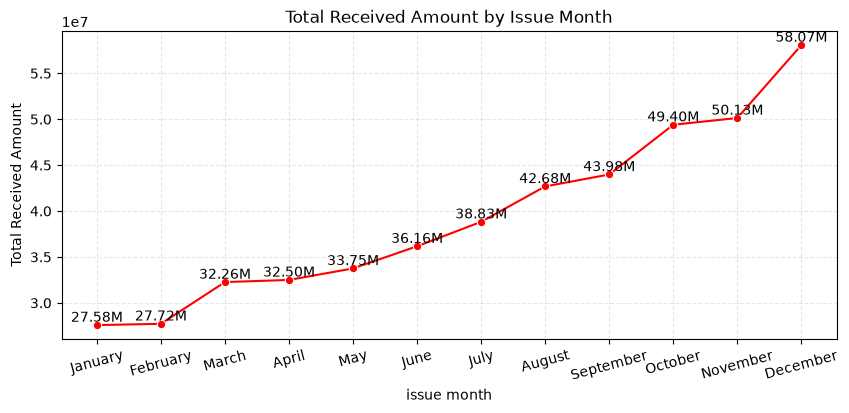

In [40]:
y_axis = total_received_amount
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_trend, x='issue month', y=y_axis, color='red', marker='o')
plt.xticks(rotation=15)
plt.title(f'{y_axis} by Issue Month')
plt.grid(linestyle='dashed', alpha=0.3)

showValue(monthly_trend, y_axis)

plt.show()